# SIP Monte Carlo Walkthrough: ₹15,000/month for 20 years

This notebook walks through a full example of the SIP & Wealth
Accumulation Monte Carlo Simulator: setting up a scenario, reading the
distribution of outcomes (not a single number), computing the probability
of reaching a target corpus, and reproducing the sequence-of-returns-risk
demonstration.

**Reminder: every number below is a simulated outcome under stated,
overridable assumptions. None of it is a forecast or investment advice.**


In [1]:
import sys
from pathlib import Path

# Make the local `src/` package importable without an editable install.
sys.path.insert(0, str(Path.cwd().parent / "src"))

import numpy as np
import pandas as pd

from sip_monte_carlo.engine import run_simulation, PERCENTILES
from sip_monte_carlo.closed_form import future_value_growing_annuity
from sip_monte_carlo.engine import net_monthly_rate
from sip_monte_carlo.sequence_risk import demo_sequence_of_returns_risk

pd.options.display.float_format = lambda x: f"{x:,.0f}"


## 1. Define the scenario

₹15,000/month, stepping up 5%/year, for 20 years, starting from zero,
assuming a 12%/year expected nominal return, 18%/year volatility, a 1%/year
fee drag, and 5%/year inflation. 5,000 simulated paths, fixed seed for
reproducibility.


In [2]:
scenario = dict(
    monthly_contribution=15_000,
    duration_years=20,
    expected_annual_return=0.12,
    annual_volatility=0.18,
    annual_inflation=0.05,
    contribution_growth_rate=0.05,
    initial_capital=0.0,
    annual_fee_rate=0.01,
    n_paths=5_000,
    seed=42,
)
result = run_simulation(**scenario)
result.final_summary()


,nominal,real
statistic,,
mean,"16,783,834","6,325,650"
p10,"8,576,356","3,232,339"
p25,"11,084,702","4,177,708"
p50,"14,907,616","5,618,524"
p75,"20,262,265","7,636,634"
p90,"27,217,413","10,257,957"


Note how much wider the gap is between `p10` and `p90` than between
`mean` and `median` — this is a *distribution*, and the tails matter.


## 2. Sanity check: zero volatility matches the exact closed form

Before trusting the stochastic output, confirm the deterministic
(zero-volatility) case reduces to the closed-form growing-annuity future
value exactly. This is also enforced by the automated test suite
(`tests/test_engine.py`), but it's worth seeing directly.


In [3]:
deterministic_scenario = {**scenario, "annual_volatility": 0.0, "n_paths": 1}
deterministic_result = run_simulation(**deterministic_scenario)

r = net_monthly_rate(
    scenario["expected_annual_return"],
    annual_fee_rate=scenario["annual_fee_rate"],
    annual_volatility=0.0,
)
closed_form_fv = future_value_growing_annuity(
    monthly_contribution=scenario["monthly_contribution"],
    duration_years=scenario["duration_years"],
    monthly_rate=r,
    contribution_growth_rate=scenario["contribution_growth_rate"],
    initial_capital=scenario["initial_capital"],
)

simulated_fv = deterministic_result.nominal_final[0]
print(f"Simulated (zero-vol) final value: Rs {simulated_fv:,.2f}")
print(f"Closed-form final value:          Rs {closed_form_fv:,.2f}")
print(f"Difference:                       Rs {simulated_fv - closed_form_fv:,.8f}")
assert abs(simulated_fv - closed_form_fv) < 1e-6


Simulated (zero-vol) final value: Rs 16,824,420.54
Closed-form final value:          Rs 16,824,420.54
Difference:                       Rs -0.00000002


## 3. The percentile fan over time

The full time series of percentiles (not just the final value) is where
the shape of the uncertainty becomes visible.


In [4]:
pdf = result.percentile_dataframe(real=False)
pdf.iloc[::24][["year", "p10", "p25", "p50", "p75", "p90", "mean"]]  # every 2 years


,year,p10,p25,p50,p75,p90,mean
0,0,0,0,0,0,0,0
24,2,"346,522","371,295","403,611","440,271","477,447","408,282"
48,4,"739,508","824,825","933,076","1,054,553","1,181,996","950,074"
72,6,"1,214,692","1,385,604","1,617,749","1,885,532","2,178,992","1,662,919"
96,8,"1,792,752","2,084,853","2,471,656","2,957,098","3,510,328","2,586,646"
120,10,"2,501,964","2,960,821","3,607,082","4,418,697","5,336,706","3,800,496"
144,12,"3,320,093","3,982,692","4,978,810","6,202,180","7,686,241","5,300,970"
168,14,"4,316,714","5,281,330","6,760,580","8,615,591","10,896,562","7,281,319"
192,16,"5,377,376","6,783,844","8,795,926","11,630,730","14,974,153","9,677,610"
216,18,"6,841,916","8,630,693","11,583,628","15,370,022","20,282,217","12,808,763"


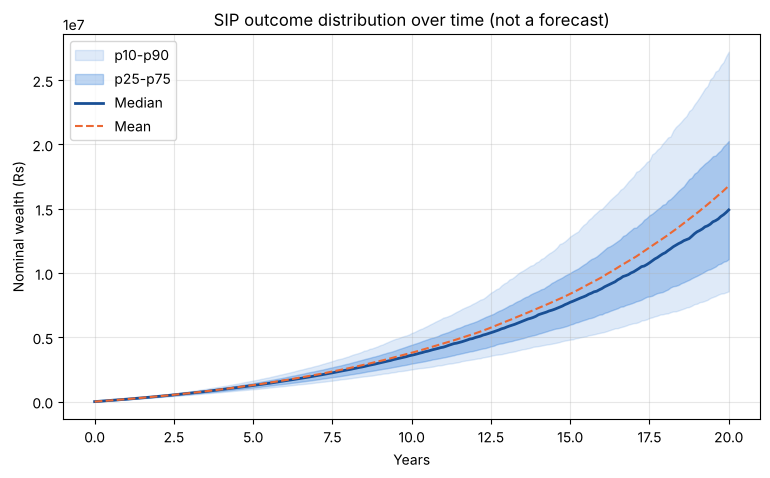

In [5]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9, 5))
ax.fill_between(pdf["year"], pdf["p10"], pdf["p90"], color="#2a78d6", alpha=0.15, label="p10-p90")
ax.fill_between(pdf["year"], pdf["p25"], pdf["p75"], color="#2a78d6", alpha=0.30, label="p25-p75")
ax.plot(pdf["year"], pdf["p50"], color="#184f95", linewidth=2, label="Median")
ax.plot(pdf["year"], pdf["mean"], color="#eb6834", linewidth=1.5, linestyle="--", label="Mean")
ax.set_xlabel("Years")
ax.set_ylabel("Nominal wealth (Rs)")
ax.set_title("SIP outcome distribution over time (not a forecast)")
ax.legend()
ax.grid(alpha=0.3)
plt.show()


## 4. Probability of reaching a target corpus

What fraction of the 5,000 simulated paths reach a chosen target, e.g.
₹1 crore (₹10,000,000), by year 20?


In [6]:
for target in [5_000_000, 10_000_000, 15_000_000, 20_000_000]:
    p = result.probability_of_reaching(target)
    print(f"P(final nominal wealth >= Rs {target:,}) = {p * 100:5.1f}%")


P(final nominal wealth >= Rs 5,000,000) =  99.6%
P(final nominal wealth >= Rs 10,000,000) =  81.9%
P(final nominal wealth >= Rs 15,000,000) =  49.3%
P(final nominal wealth >= Rs 20,000,000) =  26.2%


## 5. Volatility drag: same mean return, different median outcome

Hold the *arithmetic mean* return fixed at 12%/year and compare a
low-volatility run against a high-volatility run.


In [7]:
vol_scenarios = {}
for vol in [0.05, 0.15, 0.25, 0.35]:
    s = {**scenario, "annual_volatility": vol}
    r = run_simulation(**s)
    vol_scenarios[vol] = r

comparison = pd.DataFrame({
    "annual_volatility": list(vol_scenarios.keys()),
    "mean_final": [np.mean(r.nominal_final) for r in vol_scenarios.values()],
    "median_final": [np.median(r.nominal_final) for r in vol_scenarios.values()],
})
comparison


,annual_volatility,mean_final,median_final
0,0,"16,822,589","16,660,558"
1,0,"16,797,862","15,454,110"
2,0,"16,735,084","13,388,956"
3,0,"16,611,405","11,044,055"


Notice: the **mean** barely moves (or even drifts up slightly, from the
longer right tail of the lognormal distribution at high volatility), while
the **median** — the outcome a typical path actually experiences — falls
substantially as volatility rises. This is volatility drag / the
arithmetic-geometric mean gap, and it's a mechanical consequence of
compounding, not a market-timing story. See `docs/METHODOLOGY.md` for the
derivation.


## 6. Sequence-of-returns risk: same average, different order

A small, explicit, non-random example: the same eight annual returns, run
forward and in reverse, applied to the same annual contribution stream.


In [8]:
annual_returns = [0.30, -0.10, 0.20, -0.05, 0.15, 0.25, -0.15, 0.10]

seq_result = demo_sequence_of_returns_risk(
    annual_returns,
    annual_contribution=180_000,  # Rs 15,000/month x 12
    initial_capital=0.0,
)

print(f"Arithmetic mean return (identical both ways): {seq_result.arithmetic_mean_return * 100:.2f}%")
print(f"Final value, order as given:   Rs {seq_result.forward_final:,.0f}")
print(f"Final value, reversed order:   Rs {seq_result.reversed_final:,.0f}")
print(f"Difference:                    Rs {seq_result.difference:,.0f}  "
      f"({seq_result.percent_difference * 100:.1f}% of the reversed-order value)")


Arithmetic mean return (identical both ways): 8.75%
Final value, order as given:   Rs 1,752,464
Final value, reversed order:   Rs 2,031,974
Difference:                    Rs -279,510  (-13.8% of the reversed-order value)


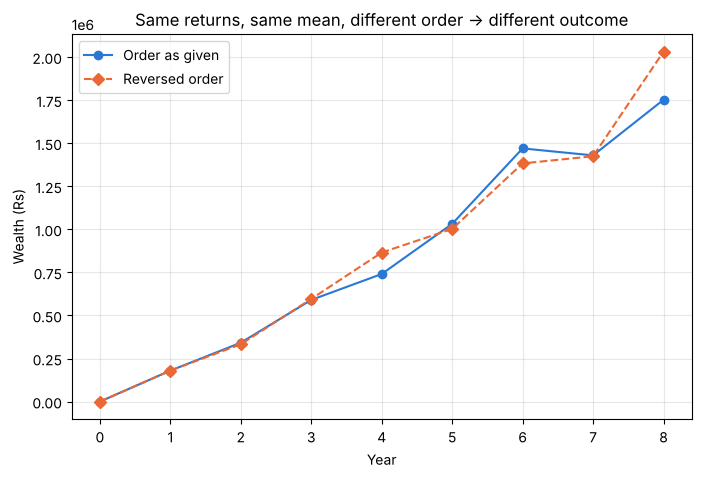

In [9]:
fig, ax = plt.subplots(figsize=(8, 5))
years = np.arange(len(annual_returns) + 1)
ax.plot(years, seq_result.forward_path, marker="o", color="#2a78d6", label="Order as given")
ax.plot(years, seq_result.reversed_path, marker="D", color="#eb6834", linestyle="--", label="Reversed order")
ax.set_xlabel("Year")
ax.set_ylabel("Wealth (Rs)")
ax.set_title("Same returns, same mean, different order -> different outcome")
ax.legend()
ax.grid(alpha=0.3)
plt.show()


## Takeaways

- A SIP projection is a *distribution*, not a single number — the p10-p90
  spread after 20 years, even under one fixed set of assumptions, is wide.
- Volatility drag means that two assumptions with the same average return
  can imply meaningfully different *typical* (median) outcomes.
- Sequence-of-returns risk means that *when* good and bad years happen
  matters, separately from how many of each there are.
- None of this is a forecast. Change the assumptions, re-run, and the
  distribution changes — that's the entire point of simulating instead of
  projecting a single curve.
